In [8]:
import pandas as pd

# Load the datasets
orders = pd.read_csv('olist_orders_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

# Convert date strings to Python datetime objects
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Merge them together
df = pd.merge(orders, customers, on='customer_id')
df = pd.merge(df, payments, on='order_id')

# Keep the columns we need for RFM
df = df[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value']]

print("Data merged! Here is the top of your new table:")
print(df.head())

Data merged! Here is the top of your new table:
                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
2  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
3  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
4  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   

  order_purchase_timestamp  payment_value  
0      2017-10-02 10:56:33          18.12  
1      2017-10-02 10:56:33           2.00  
2      2017-10-02 10:56:33          18.59  
3      2018-07-24 20:41:37         141.46  
4      2018-08-08 08:38:49         179.12  


In [9]:
# Define the snapshot date
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Group by customer and calculate RFM values
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'count',                                               # Frequency
    'payment_value': 'sum'                                             # Monetary
})

# Rename columns
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

print(rfm.head())

                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19
0000f46a3911fa3c0805444483337064      586          1     86.22
0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62
0004aac84e0df4da2b147fca70cf8255      337          1    196.89


In [10]:
# Create labels for our quintiles
r_labels = range(5, 0, -1) # 5 is best (most recent), 1 is worst
f_labels = range(1, 6)      # 5 is best (most frequent), 1 is worst
m_labels = range(1, 6)      # 5 is best (highest spend), 1 is worst

# Assign these labels to 5 groups
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# Create a combined RFM Score
rfm['RFM_Group'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# Calculate a total sum score for easier sorting
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

print(rfm.head())

                                  Recency  Frequency  Monetary  R  F  M  \
customer_unique_id                                                        
0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90  4  1  4   
0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19  4  1  1   
0000f46a3911fa3c0805444483337064      586          1     86.22  1  1  2   
0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62  2  1  1   
0004aac84e0df4da2b147fca70cf8255      337          1    196.89  2  1  4   

                                 RFM_Group  RFM_Score  
customer_unique_id                                     
0000366f3b9a7992bf8c76cfdf3221e2       414          9  
0000b849f77a49e4a4ce2b2a4ca5be3f       411          6  
0000f46a3911fa3c0805444483337064       112          4  
0000f6ccb0745a6a4b88665a16c9f078       211          4  
0004aac84e0df4da2b147fca70cf8255       214          7  


In [11]:
# Define a function to organize customers based on their RFM_Score
def segment_me(df):
    if df['RFM_Score'] >= 12:
        return 'Champions'
    elif (df['RFM_Score'] >= 10) and (df['RFM_Score'] < 12):
        return 'Loyal Customers'
    elif (df['RFM_Score'] >= 8) and (df['RFM_Score'] < 10):
        return 'Potential Loyalists'
    elif (df['RFM_Score'] >= 6) and (df['RFM_Score'] < 8):
        return 'At Risk'
    else:
        return 'Hibernating / Lost'

# Apply the function to the RFM dataframe
rfm['Segment'] = rfm.apply(segment_me, axis=1)

# See how many customers fall into each category
print(rfm['Segment'].value_counts())

Segment
Potential Loyalists    28207
Loyal Customers        24745
At Risk                19191
Champions              15910
Hibernating / Lost      8042
Name: count, dtype: int64


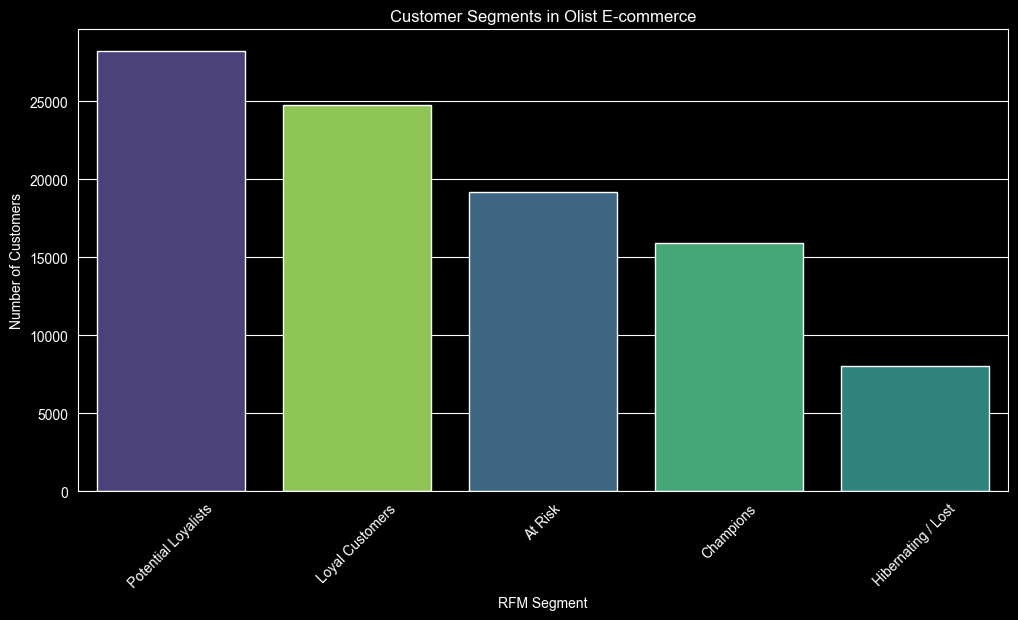

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.countplot(
    data=rfm,
    x='Segment',
    hue='Segment',
    palette='viridis',
    legend=False,
    order=rfm['Segment'].value_counts().index
)

plt.title('Customer Segments in Olist E-commerce')
plt.ylabel('Number of Customers')
plt.xlabel('RFM Segment')
plt.xticks(rotation=45)
plt.show()

In [14]:
rfm.to_csv('olist_rfm_analysis.csv')
print("File saved! Check your PythonProject folder.")

File saved! Check your PythonProject folder.
